# Greenfilling trade-offs

An exploratory look at the full 28-day campaign. The goal is to get a feel for what greenfilling (optimizing either carbon or water) does to the environmental footprint and to job performance, compared to plain EASY backfilling on the same workload and the same environmental window.

The campaign samples 36 windows of about four weeks each, spread across three grids (DE, FR, PL) and the four seasons, and runs two Mustang workloads on every window: `stress` and `slack`. The stress workload keeps the machine busy, so there is not much room in the schedule to play with, and I would expect any environmental effect to be small there. The slack workload submits roughly twice as many jobs over the same 28-day window but with more scheduling slack, so in principle the backfiller has more freedom to react to the signal. The analysis below keeps the two workloads separate so the comparison stays paired and fair.

This analysis looks at replay jobs separately before saying anything about performance.

## Load Campaign Metadata

In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

import campaign_analysis as ca

pd.set_option("display.max_columns", 120)
plt.rcParams.update({"figure.dpi": 120, "axes.grid": True, "grid.alpha": 0.25})

root = Path.cwd()
if not (root / "experiments").exists():
    root = root.parent

# Campaign this notebook renders. None is the full 28-day campaign; a string
# (e.g. "small") selects that campaign instead. Each campaign has its own TOML,
# windows manifest, and out-directory prefix, all derived from this one value.
campaign = None
campaign_prefix = f"{campaign}_" if campaign else ""

if campaign:
    campaign_path = root / "experiments" / f"experiments_{campaign}.toml"
    windows_path = root / "intensities" / "traces" / campaign / "windows.csv"
else:
    campaign_path = root / "experiments" / "experiments.toml"
    windows_path = root / "intensities" / "windows.csv"
out_dir = root / "experiments" / "out"

print(f"campaign: {campaign_path}")
print(f"windows: {windows_path}")
print(f"outputs: {out_dir}")

campaign: /Users/lucas/ws/doct/experimental-artifacts/experiments/experiments.toml
windows: /Users/lucas/ws/doct/experimental-artifacts/intensities/windows.csv
outputs: /Users/lucas/ws/doct/experimental-artifacts/experiments/out


In [2]:
campaign_df, windows = ca.load_campaign(campaign_path, windows_path, campaign_prefix)

display(campaign_df.head())
display(windows.head())

,name,workload,platform,environmental_trace,variant_name,variant_options,variant,objective,workload_label,zone,start_date
0,easy_bf_slack_DE_2019-02-04,../workloads and platforms/mustang_slack.json,../workloads and platforms/mustang.xml,../intensities/traces/DE_2019-02-04.csv,easy_bf,,easy_bf,baseline,slack,DE,2019-02-04
1,easy_bf_slack_DE_2019-07-01,../workloads and platforms/mustang_slack.json,../workloads and platforms/mustang.xml,../intensities/traces/DE_2019-07-01.csv,easy_bf,,easy_bf,baseline,slack,DE,2019-07-01
2,easy_bf_slack_DE_2019-11-25,../workloads and platforms/mustang_slack.json,../workloads and platforms/mustang.xml,../intensities/traces/DE_2019-11-25.csv,easy_bf,,easy_bf,baseline,slack,DE,2019-11-25
3,easy_bf_slack_DE_2021-04-05,../workloads and platforms/mustang_slack.json,../workloads and platforms/mustang.xml,../intensities/traces/DE_2021-04-05.csv,easy_bf,,easy_bf,baseline,slack,DE,2021-04-05
4,easy_bf_slack_DE_2021-06-07,../workloads and platforms/mustang_slack.json,../workloads and platforms/mustang.xml,../intensities/traces/DE_2021-06-07.csv,easy_bf,,easy_bf,baseline,slack,DE,2021-06-07


,zone,file,start_date,season,year,mean_carbon,mean_water,swing_carbon,swing_water
0,DE,traces/DE_2019-02-04.csv,2019-02-04,winter,2019,353.0408,1.5175,0.3195,0.3156
1,DE,traces/DE_2019-07-01.csv,2019-07-01,summer,2019,329.5072,1.7950,0.5157,0.5225
2,DE,traces/DE_2019-11-25.csv,2019-11-25,autumn,2019,310.1717,1.4219,0.3846,0.2939
3,DE,traces/DE_2021-04-05.csv,2021-04-05,spring,2021,310.8788,1.4464,0.5105,0.4568
4,DE,traces/DE_2021-06-07.csv,2021-06-07,summer,2021,354.3108,1.9153,0.5170,0.5608


## Check Result Completeness

In [3]:
result_files = ca.check_completeness(campaign_df, out_dir)

display(ca.completeness_summary(result_files))

missing = ca.missing_results(result_files)
if missing.empty:
    print(f"All {len(result_files)} experiments have schedule and job outputs.")
else:
    display(missing.sort_values(["variant", "workload_label", "zone", "start_date"]))

has_directory  has_schedule  has_jobs  \
variant             workload_label                                          
easy_bf             slack                      36            36        36   
                    stress                     36            36        36   
greenfilling_carbon slack                      36            36        36   
                    stress                     36            36        36   
greenfilling_water  slack                      36            36        36   
                    stress                     36            36        36   

                                    has_environmental_footprint  
variant             workload_label                               
easy_bf             slack                                    36  
                    stress                                   36  
greenfilling_carbon slack                                    36  
                    stress                                   36  
greenfilling_water  slack                                    36  
                    stress                                   36

All 216 experiments have schedule and job outputs.


## Load Result Tables

This section builds the reusable tables for the rest of the notebook. `schedules` has one row per experiment. `jobs` has one row per simulated job and labels each job as either `context` or `replay`.

For slowdown, the main metric is average bounded slowdown with a 10-second floor: `max(turnaround_time / max(execution_time, 10), 1)`. This keeps very short jobs from dominating the comparison while preserving the direction of the performance trade-off.

In [4]:
schedules, jobs = ca.load_results(campaign_df, result_files, out_dir, windows)

print(f"schedules: {len(schedules)} rows")
print(f"jobs: {len(jobs)} rows")

display(schedules[["name", "variant", "zone", "start_date", "season", "nb_jobs", "success_rate"]].head())
print(f"bounded slowdown floor: {ca.BOUNDED_SLOWDOWN_FLOOR_SECONDS:g} seconds")
display(jobs[["name", "job_id", "job_kind", "final_state", "waiting_time", "stretch", "bounded_slowdown"]].head())

schedules: 216 rows
jobs: 1713420 rows


,name,variant,zone,start_date,season,nb_jobs,success_rate
0,easy_bf_slack_DE_2019-02-04,easy_bf,DE,2019-02-04,winter,10745,0.924244
1,easy_bf_slack_DE_2019-07-01,easy_bf,DE,2019-07-01,summer,10745,0.924244
2,easy_bf_slack_DE_2019-11-25,easy_bf,DE,2019-11-25,autumn,10745,0.924244
3,easy_bf_slack_DE_2021-04-05,easy_bf,DE,2021-04-05,spring,10745,0.924244
4,easy_bf_slack_DE_2021-06-07,easy_bf,DE,2021-06-07,summer,10745,0.924244


bounded slowdown floor: 10 seconds


,name,job_id,job_kind,final_state,waiting_time,stretch,bounded_slowdown
0,easy_bf_slack_DE_2019-02-04,ctx_queued1,context,COMPLETED_SUCCESSFULLY,0.0,1.000000,1.000000
1,easy_bf_slack_DE_2019-02-04,ctx_queued2,context,COMPLETED_SUCCESSFULLY,5.0,2.000000,1.000000
2,easy_bf_slack_DE_2019-02-04,ctx_queued12,context,COMPLETED_SUCCESSFULLY,0.0,1.000000,1.000000
3,easy_bf_slack_DE_2019-02-04,ctx_queued36,context,COMPLETED_SUCCESSFULLY,10.0,1.555556,1.555556
4,easy_bf_slack_DE_2019-02-04,ctx_queued17,context,COMPLETED_SUCCESSFULLY,0.0,1.000000,1.000000


In [5]:
job_metrics = ca.build_job_metrics(jobs)

display(ca.summarize_job_metrics(job_metrics))
display(job_metrics.head())

runs  jobs_per_run  \
workload_label variant             job_kind                       
slack          easy_bf             context     36          62.0   
                                   replay      36       10683.0   
               greenfilling_carbon context     36          62.0   
                                   replay      36       10683.0   
               greenfilling_water  context     36          62.0   
                                   replay      36       10683.0   
stress         easy_bf             context     36          31.0   
                                   replay      36        5089.0   
               greenfilling_carbon context     36          31.0   
                                   replay      36        5089.0   
               greenfilling_water  context     36          31.0   
                                   replay      36        5089.0   

                                             median_success_rate  \
workload_label variant             job_kind                        
slack          easy_bf             context                 0.984   
                                   replay                  0.924   
               greenfilling_carbon context                 0.968   
                                   replay                  0.921   
               greenfilling_water  context                 0.968   
                                   replay                  0.922   
stress         easy_bf             context                 1.000   
                                   replay                  0.936   
               greenfilling_carbon context                 0.968   
                                   replay                  0.935   
               greenfilling_water  context                 0.968   
                                   replay                  0.934   

                                             min_success_rate  \
workload_label variant             job_kind                     
slack          easy_bf             context              0.984   
                                   replay               0.924   
               greenfilling_carbon context              0.887   
                                   replay               0.919   
               greenfilling_water  context              0.871   
                                   replay               0.918   
stress         easy_bf             context              1.000   
                                   replay               0.936   
               greenfilling_carbon context              0.903   
                                   replay               0.931   
               greenfilling_water  context              0.935   
                                   replay               0.932   

                                             max_success_rate  \
workload_label variant             job_kind                     
slack          easy_bf             context              0.984   
                                   replay               0.924   
               greenfilling_carbon context              1.000   
                                   replay               0.923   
               greenfilling_water  context              1.000   
                                   replay               0.925   
stress         easy_bf             context              1.000   
                                   replay               0.936   
               greenfilling_carbon context              1.000   
                                   replay               0.939   
               greenfilling_water  context              1.000   
                                   replay               0.937   

                                             median_walltime_reached  \
workload_label variant             job_kind                            
slack          easy_bf             context                       1.0   
                                   replay                      813.0   
               greenfilling_carbon context 

,name,variant,workload_label,zone,start_date,job_kind,jobs,succeeded,walltime_reached,success_rate,median_waiting_time,p95_waiting_time,mean_bounded_slowdown
0,easy_bf_slack_DE_2019-02-04,easy_bf,slack,DE,2019-02-04,context,62,61,1,0.983871,10.0,56544.85,7.031552
1,easy_bf_slack_DE_2019-02-04,easy_bf,slack,DE,2019-02-04,replay,10683,9870,813,0.923898,12.0,53456.80,65.532318
2,easy_bf_slack_DE_2019-07-01,easy_bf,slack,DE,2019-07-01,context,62,61,1,0.983871,10.0,56544.85,7.031552
3,easy_bf_slack_DE_2019-07-01,easy_bf,slack,DE,2019-07-01,replay,10683,9870,813,0.923898,12.0,53456.80,65.532318
4,easy_bf_slack_DE_2019-11-25,easy_bf,slack,DE,2019-11-25,context,62,61,1,0.983871,10.0,56544.85,7.031552


## Paired comparison: greenfilling versus EASY

The traces differ by country and window, and there are two workloads, so I compare paired by `(workload, zone, start_date)`: each greenfilling run sits next to the EASY run from the same workload, platform, and window. Percentages below are relative to EASY in that same workload and window. Results are kept split by workload throughout so stress and slack are never averaged together.

For performance I look at replay jobs only. Context jobs are the initial backlog, and folding them in would mix warm-up with the behavior I actually care about. One caveat to keep in mind: the schedulers do not kill the same jobs, so the waiting and slowdown averages are over slightly different survivors. I read them next to success rate and walltime hits rather than on their own.

In [6]:
run_metrics = ca.build_run_metrics(schedules, job_metrics)

display(run_metrics.head())

,name,variant,workload_label,zone,start_date,season,swing_carbon,swing_water,total_carbon_footprint,total_water_footprint,makespan,replay_jobs,replay_succeeded,replay_walltime_reached,replay_success_rate,replay_median_waiting_time,replay_p95_waiting_time,replay_mean_bounded_slowdown
0,easy_bf_slack_DE_2019-02-04,easy_bf,slack,DE,2019-02-04,winter,0.3195,0.3156,1.084528e+08,466098.524103,2467562.0,10683,9870,813,0.923898,12.0,53456.8,65.532318
1,easy_bf_slack_DE_2019-07-01,easy_bf,slack,DE,2019-07-01,summer,0.5157,0.5225,1.025825e+08,558514.573227,2467562.0,10683,9870,813,0.923898,12.0,53456.8,65.532318
2,easy_bf_slack_DE_2019-11-25,easy_bf,slack,DE,2019-11-25,autumn,0.3846,0.2939,9.562338e+07,439218.659147,2467562.0,10683,9870,813,0.923898,12.0,53456.8,65.532318
3,easy_bf_slack_DE_2021-04-05,easy_bf,slack,DE,2021-04-05,spring,0.5105,0.4568,9.553711e+07,445302.301230,2467562.0,10683,9870,813,0.923898,12.0,53456.8,65.532318
4,easy_bf_slack_DE_2021-06-07,easy_bf,slack,DE,2021-06-07,summer,0.5170,0.5608,1.104293e+08,596156.204934,2467562.0,10683,9870,813,0.923898,12.0,53456.8,65.532318


The table below summarizes paired deltas across the 36 windows. Percentages are relative to EASY in the same window. `replay_walltime_reached_delta` is an absolute change, in jobs, in the number of replay jobs that hit walltime.

In [7]:
paired_comparisons = ca.build_paired_comparisons(run_metrics)

display(ca.summarize_paired(paired_comparisons))
display(
    paired_comparisons[
        ["greenfilling_variant", "workload_label", "zone", "season", "start_date"]
        + ca.DELTA_COLUMNS[1:]
    ].head()
)

total_carbon_footprint_delta_pct        \
                                                              median   min   
workload_label greenfilling_variant                                          
slack          greenfilling_carbon                             -0.07 -0.36   
               greenfilling_water                              -0.04 -0.25   
stress         greenfilling_carbon                              0.01 -0.40   
               greenfilling_water                               0.07 -0.29   

                                          total_water_footprint_delta_pct  \
                                      max                          median   
workload_label greenfilling_variant                                         
slack          greenfilling_carbon   0.41                           -0.06   
               greenfilling_water    0.10                           -0.03   
stress         greenfilling_carbon   0.64                            0.02   
               greenfilling_water    0.71                            0.04   

                                                makespan_delta_pct        \
                                      min   max             median   min   
workload_label greenfilling_variant                                        
slack          greenfilling_carbon  -0.25  0.30               0.00  0.00   
               greenfilling_water   -0.17  0.08               0.00  0.00   
stress         greenfilling_carbon  -0.27  0.47               1.25  1.06   
               greenfilling_water   -0.31  0.23               1.33  0.81   

                                          replay_success_rate_delta_pct        \
                                      max                        median   min   
workload_label greenfilling_variant                                             
slack          greenfilling_carbon   0.00                         -0.27 -0.50   
               greenfilling_water    0.00                         -0.26 -0.61   
stress         greenfilling_carbon   1.78                         -0.09 -0.48   
               greenfilling_water    1.83                         -0.14 -0.42   

                                          replay_walltime_reached_delta      \
                                      max                        median min   
workload_label greenfilling_variant                                           
slack          greenfilling_carbon  -0.09                          26.5   9   
               greenfilling_water    0.09                          25.5  -9   
stress         greenfilling_carbon   0.38                           4.5 -18   
               greenfilling_water    0.08                           6.5  -4   

                                        replay_median_waiting_time_delta_pct  \
                                    max                               median   
workload_label greenfilling_variant                                            
slack          greenfilling_carbon   49                             52616.67   
               greenfilling_water    60                             45141.67   
stress         greenfilling_carbon   23                                  inf   
               greenfilling_water    20                                  inf   

                                                         \
                                          min       max   
workload_label greenfilling_variant                       
slack          greenfilling_carbon   31316.67  76200.00   
               greenfilling_water    15866.67  92858.33   
stress         greenfilling_carbon        inf       inf   
               greenfilling_water         inf       inf   

                                    replay_p95_waiting_time_delta_pct         \
                                                               median    min   
workload_label greenfilling_variant                                            
slack          greenfilling_carbon                              53.16  32.75   

,greenfilling_variant,workload_label,zone,season,start_date,total_carbon_footprint_delta_pct,total_water_footprint_delta_pct,makespan_delta_pct,replay_success_rate_delta_pct,replay_walltime_reached_delta,replay_median_waiting_time_delta_pct,replay_p95_waiting_time_delta_pct,replay_mean_bounded_slowdown_delta_pct
0,greenfilling_carbon,slack,DE,winter,2019-02-04,0.030107,0.023351,0.0,-0.202634,20,64683.333333,50.558582,477.261614
1,greenfilling_carbon,slack,DE,summer,2019-07-01,-0.246137,-0.192239,0.0,-0.202634,20,76200.000000,61.187538,417.682324
2,greenfilling_carbon,slack,DE,autumn,2019-11-25,-0.043192,-0.037777,0.0,-0.162107,16,35225.000000,57.304964,312.320451
3,greenfilling_carbon,slack,DE,spring,2021-04-05,-0.022364,-0.010103,0.0,-0.253293,25,59175.000000,57.845026,374.138067
4,greenfilling_carbon,slack,DE,summer,2021-06-07,-0.229301,-0.185811,0.0,-0.354610,35,63133.333333,54.905082,315.336456


## Distributions of deltas versus EASY

Each point is one sampled window, and the box just summarizes the spread across windows. Within each objective the two workloads sit side by side (color encodes workload). The line at zero is "no change from EASY." Below zero means lower footprint, waiting time, slowdown, or walltime hits than EASY.

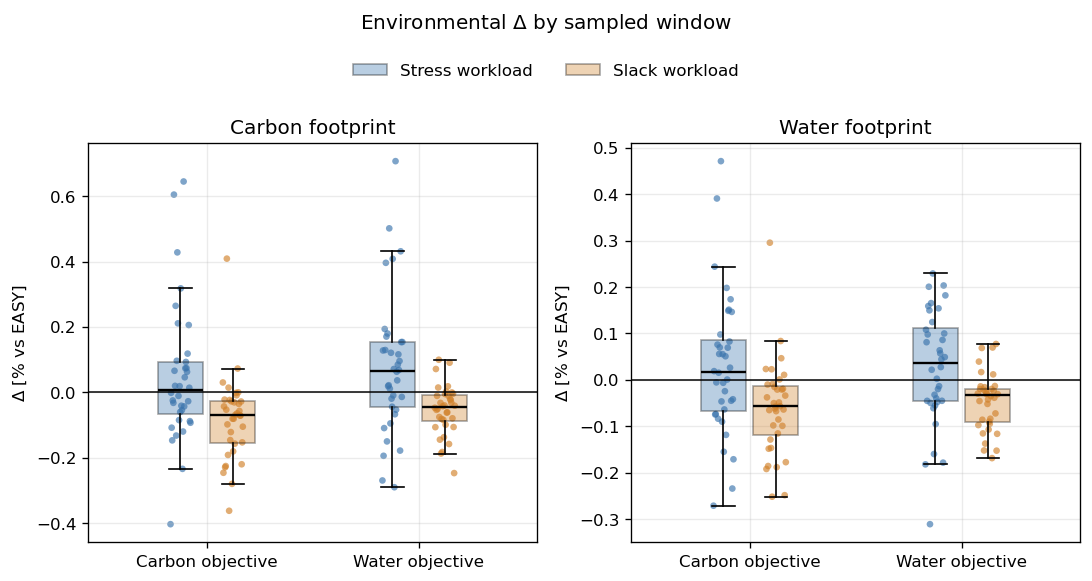

In [8]:
ca.plot_environmental_deltas(paired_comparisons);

This is the basic question: does greenfilling actually move the footprint it targets? Because the comparison is paired by window, a change in a high-carbon window and one in a low-carbon window each count on their own. The spread is small for both workloads, and neither median saving clears about a tenth of a percent. On stress the median sits slightly on the wrong side of zero. The slack workload, with its extra scheduling room, manages only a hair more saving, so the extra room does not translate into a real environmental gain here.

/nix/store/s6zf03n4lx7q8rbxxnl019z2xnn4bpb9-python3-3.13.13-env/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:4596: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = b - a


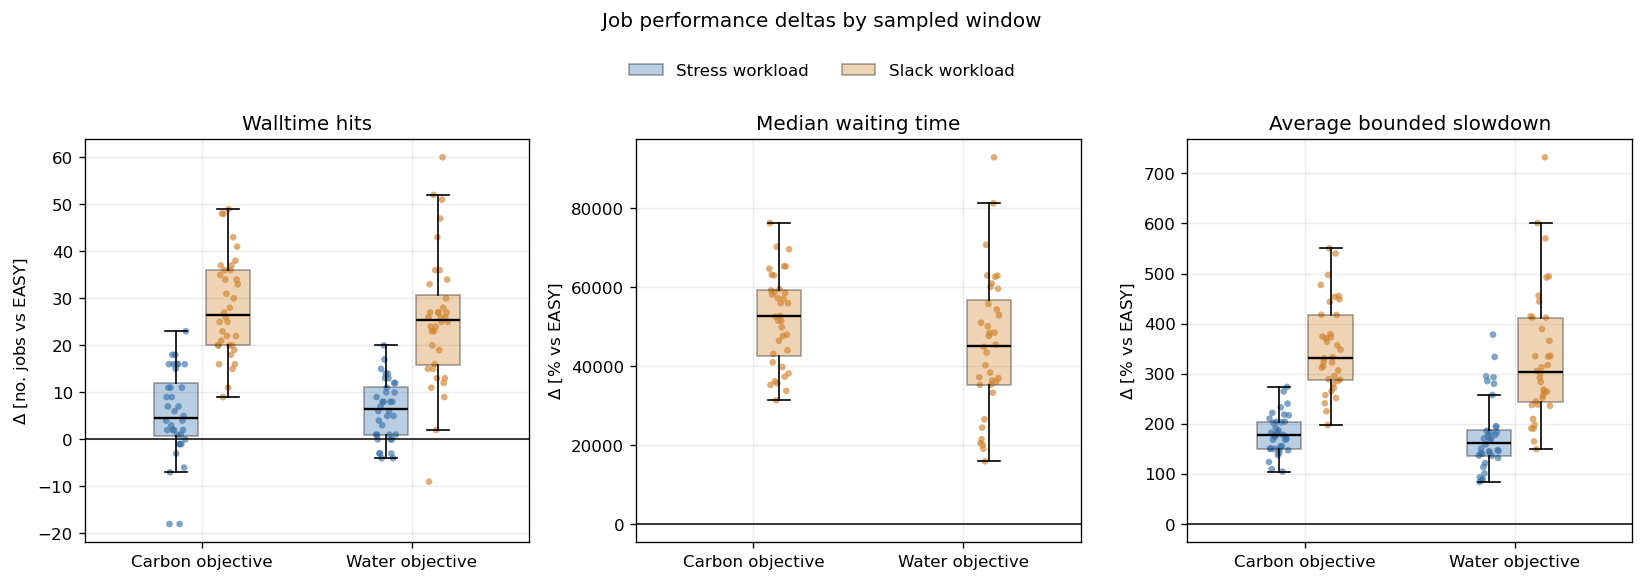

In [9]:
ca.plot_performance_deltas(paired_comparisons);

Here the point is what that footprint change costs on the replay jobs. An environmental gain matters less if it comes with more killed jobs or a jump in slowdown, so it is worth checking how the performance cost compares to the (small) footprint movement.

## Environmental saving versus performance penalty

The boxes above show each axis on its own. The next two scatters try to show the trade-off directly: one point per window, environmental saving on x, replay slowdown penalty on y. Rows are the two workloads and columns are zones. Roughly, lower-right is the nice region (less footprint, no extra slowdown), upper-right is a real trade-off, and left of zero means the footprint got worse in that window.

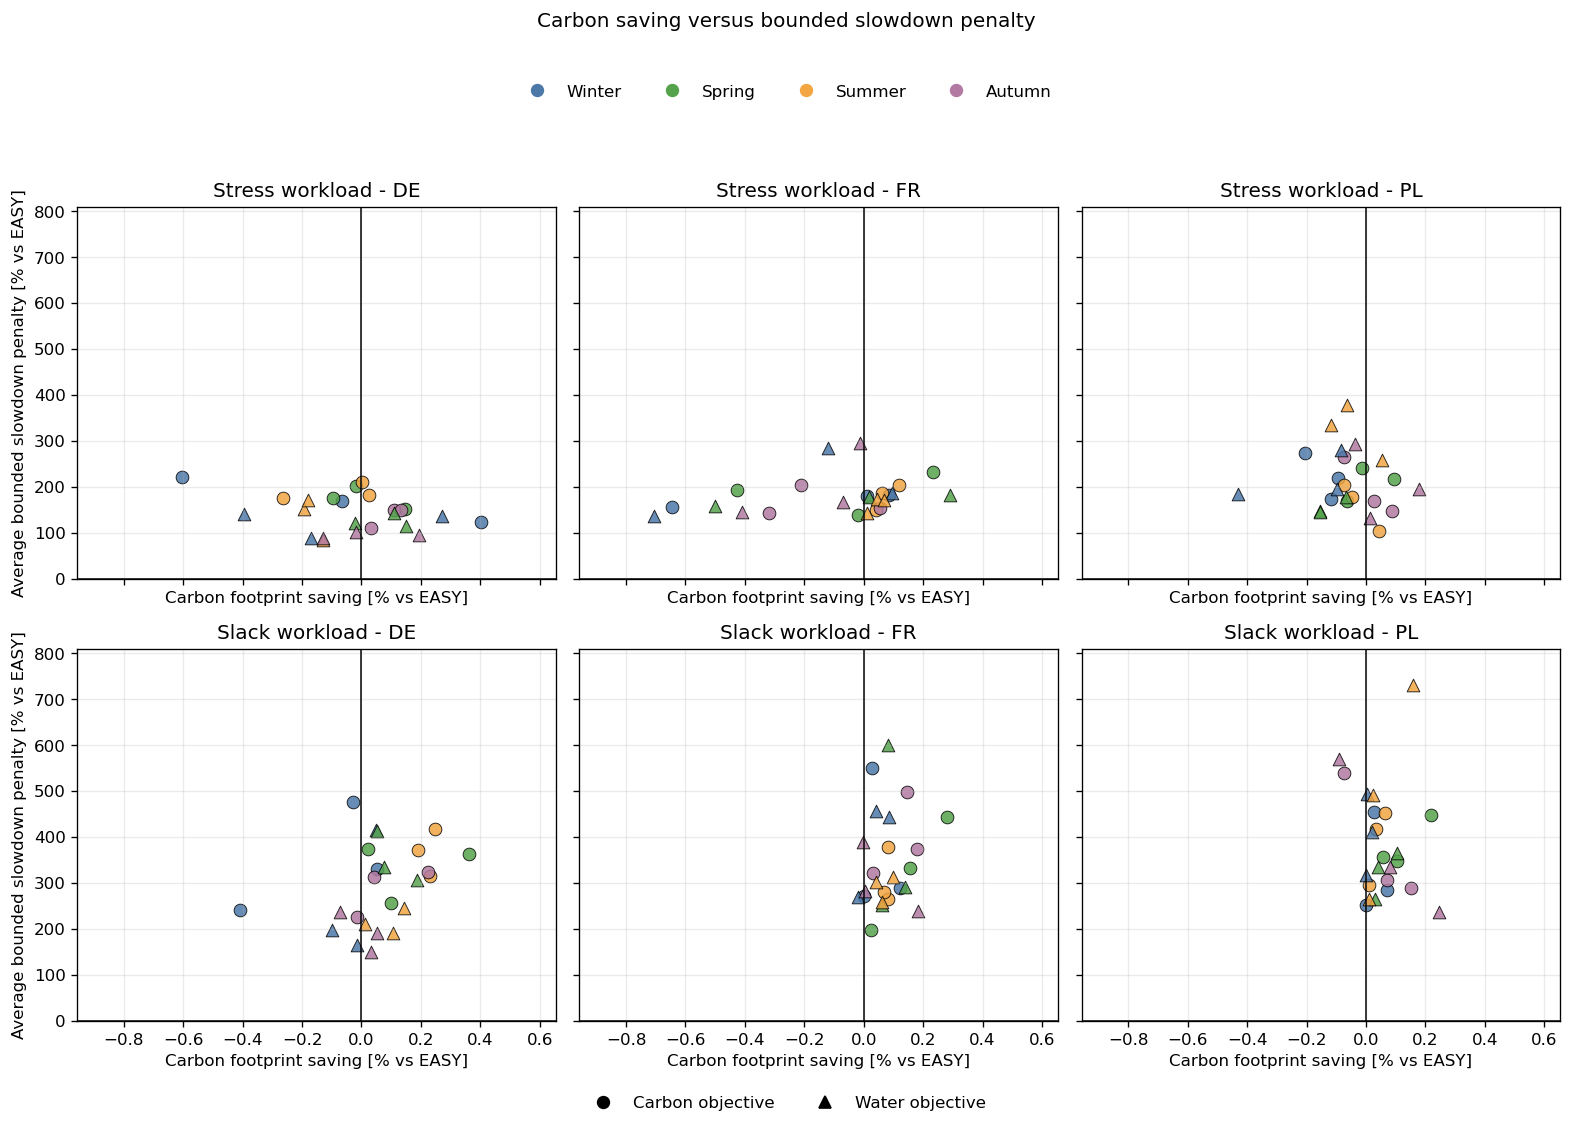

In [10]:
ca.plot_tradeoff_scatter(
    paired_comparisons,
    "total_carbon_footprint_delta_pct",
    "Carbon footprint saving [% vs EASY]",
    "Carbon saving versus bounded slowdown penalty",
);

Carbon saving on the x-axis. I keep the water-objective points in too, since a scheduler tuned for one signal might still move the other.

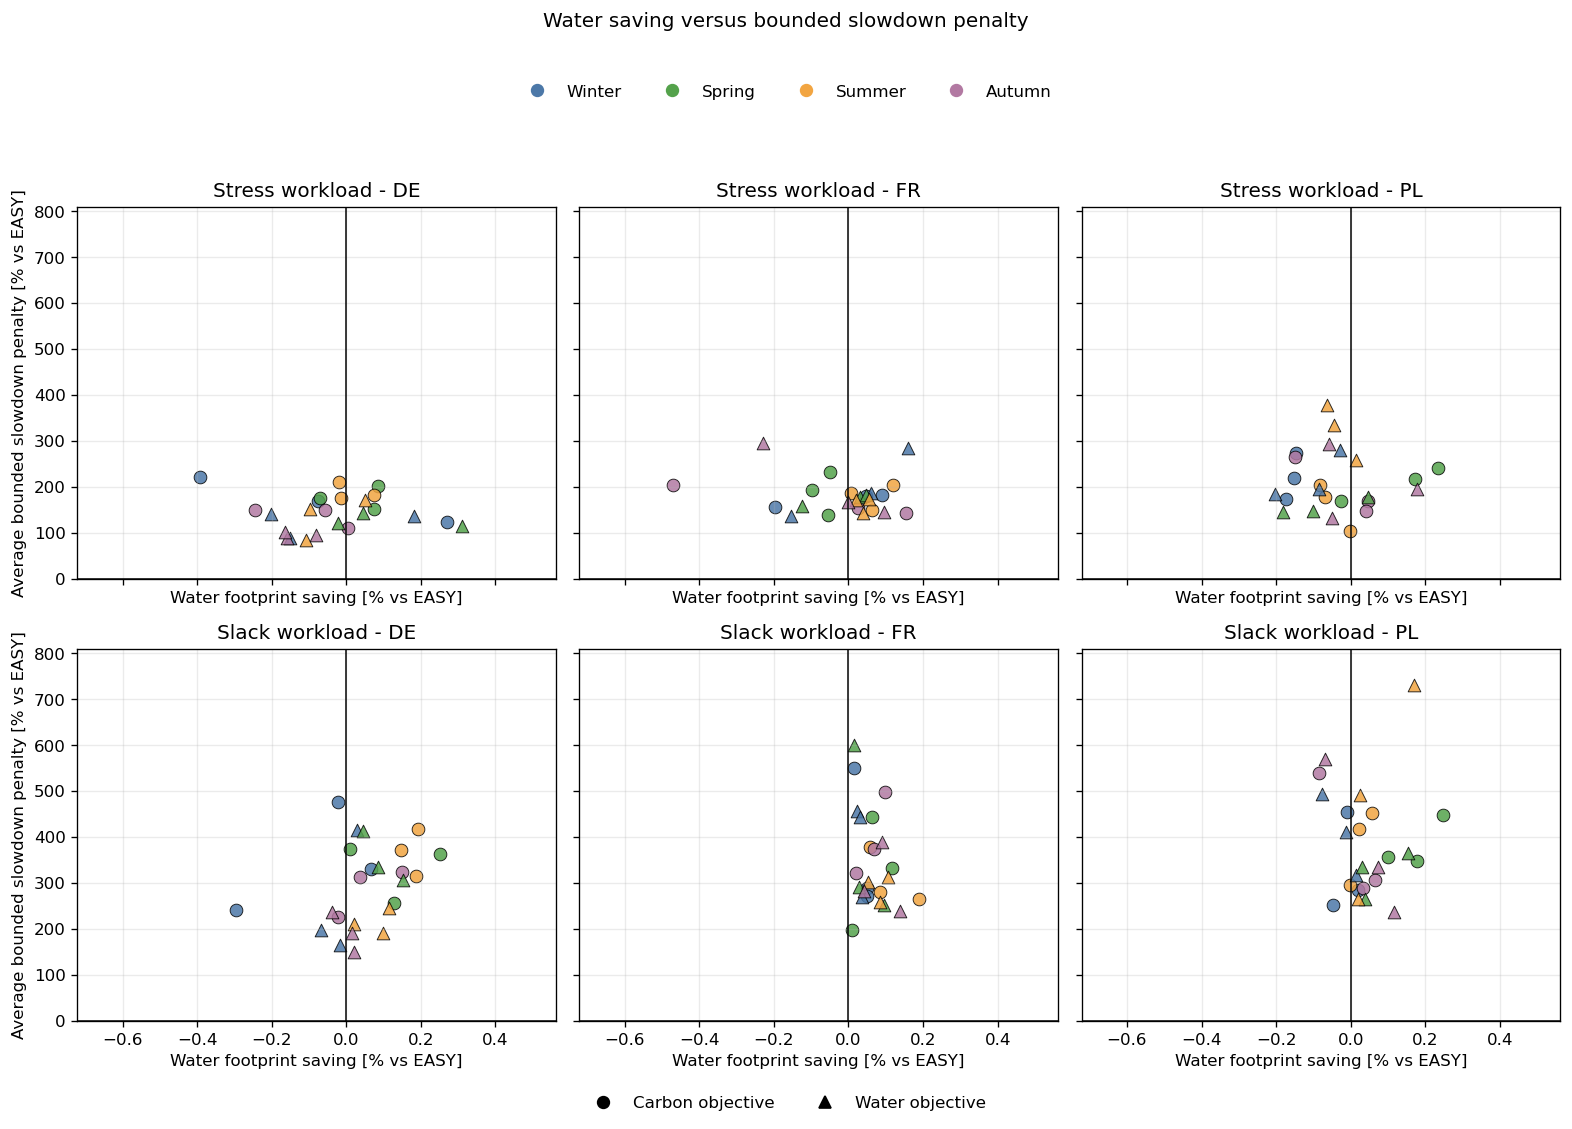

In [11]:
ca.plot_tradeoff_scatter(
    paired_comparisons,
    "total_water_footprint_delta_pct",
    "Water footprint saving [% vs EASY]",
    "Water saving versus bounded slowdown penalty",
);

Same view for water. Putting it beside the carbon figure gives a rough sense of whether optimizing one signal helps or fights the other.

## Benefit-cost view: walltime hits

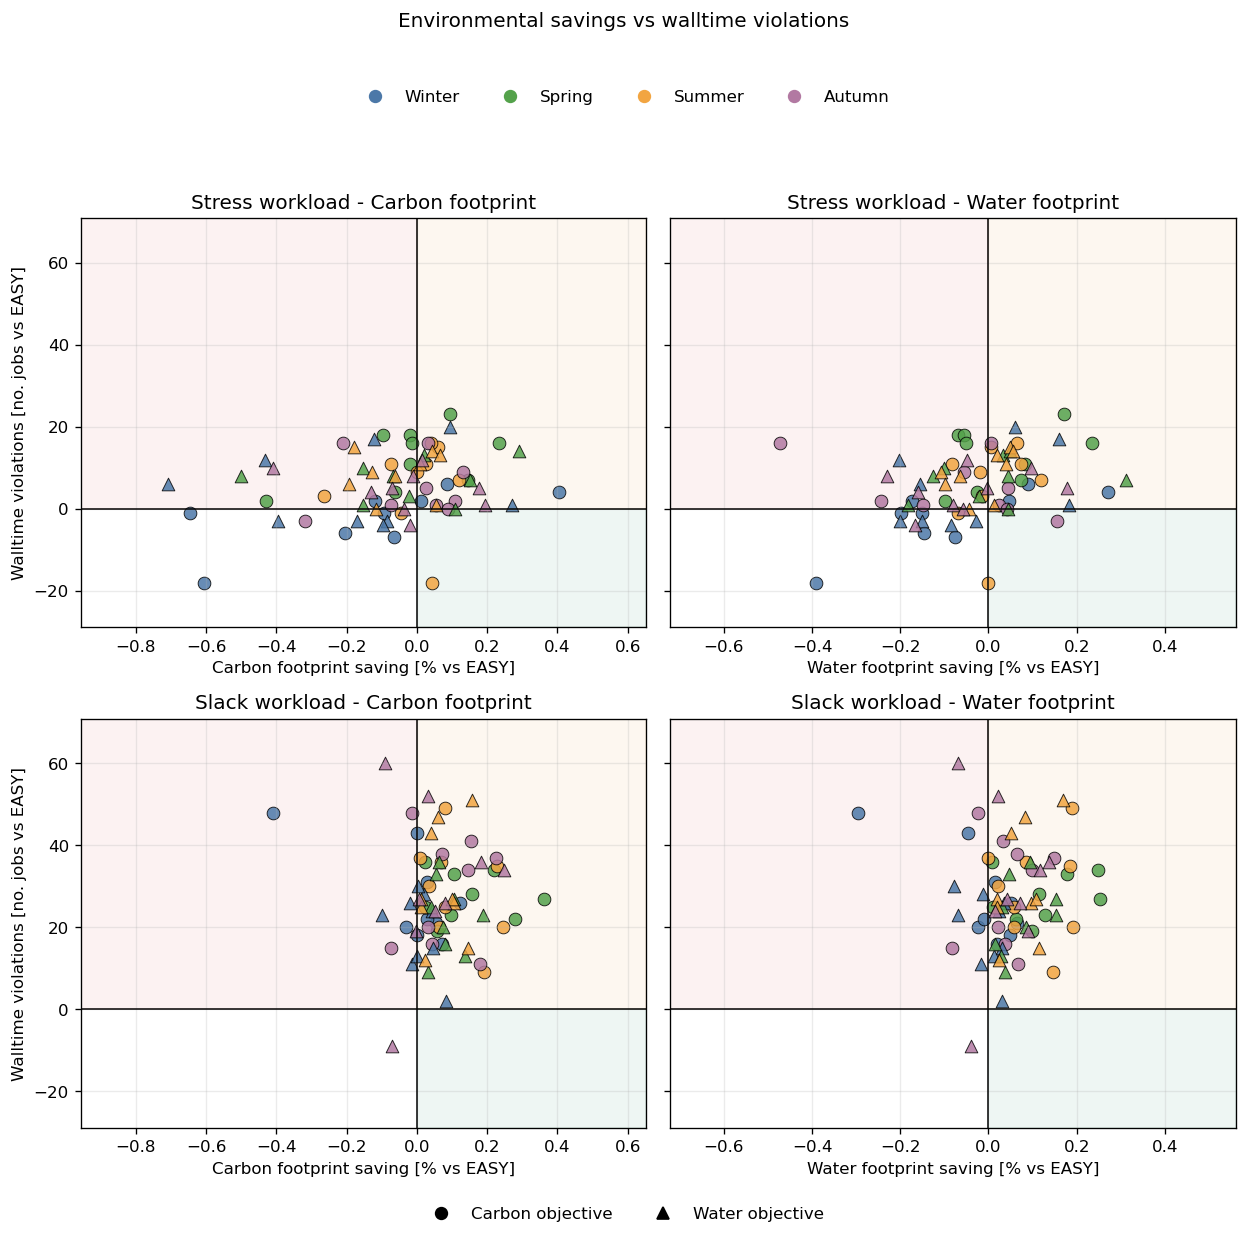

In [12]:
ca.plot_benefit_cost_quadrants(paired_comparisons);

This swaps the soft slowdown penalty for a harder one: the change in replay jobs that hit walltime. Lower-right is best (saving with no extra walltime hits), upper-right is the explicit trade-off, and upper-left would be the bad corner, worse footprint and more jobs killed.

## Does swing line up with the savings?

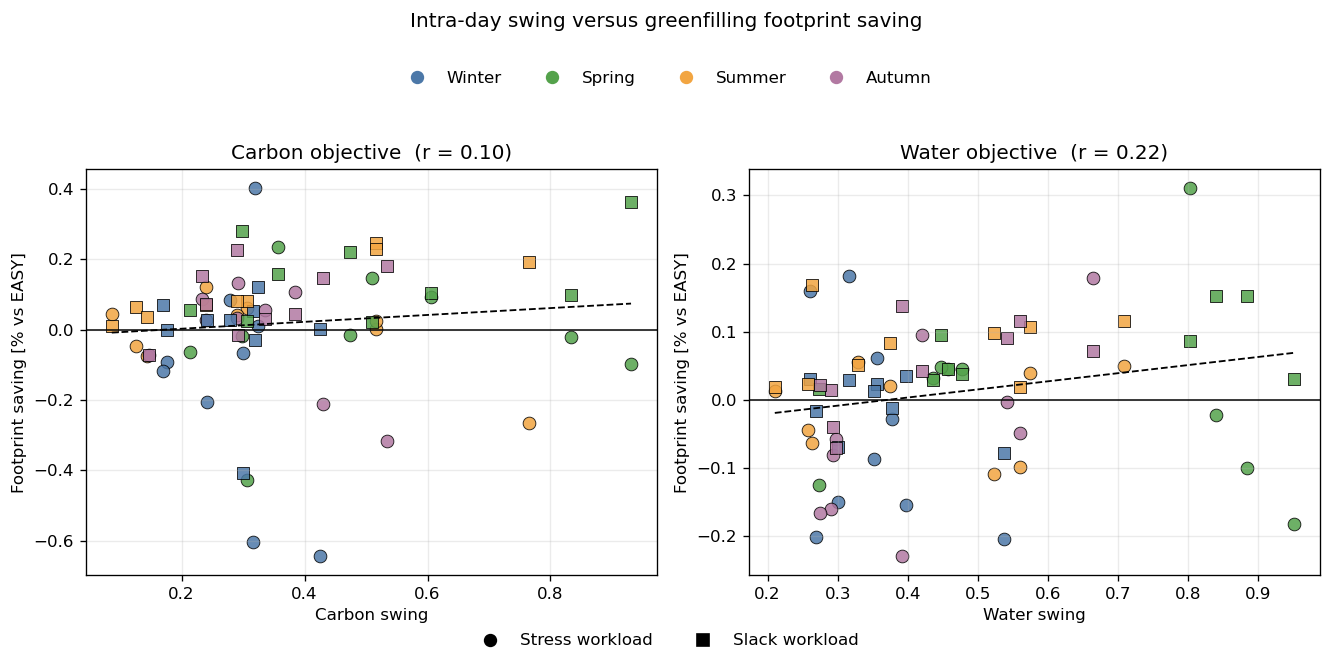

In [13]:
ca.plot_swing_relationship(paired_comparisons);

`swing` is the mean daily peak-to-trough range of a signal over the window mean, so it is a rough proxy for how much daily variation the signal has. The loose idea is that more variation might give the scheduler more to work with, so savings could grow with swing. Each panel pairs a signal's swing with greenfilling's saving for the matching objective; both workloads share the panel (marker shape encodes workload), and the dashed least-squares fit and `r` pool all points across both workloads. With 72 windows per objective and sub-percent effects this is suggestive at best, and I would not lean on the exact value.

## Takeaway

On the stress workload, greenfilling barely moves the footprint it targets (median around 0% vs EASY, and slightly the wrong way for both objectives), while the replay jobs pay for it: median bounded slowdown is up roughly 160-180%, more replay jobs hit walltime (median around +5 vs EASY), success rate slips a fraction of a percent, and makespan grows about 1.3%. The carbon and water objectives look about the same.

The slack workload does not behave the way I expected. I added it thinking more scheduling room would let greenfilling find a larger environmental gain. Instead the footprint still barely moves (median saving under a tenth of a percent), while the performance cost is larger than on stress: median bounded slowdown is up roughly 300-330%, around 25 more replay jobs hit walltime, and p95 waiting time rises about 45-53%. So the extra room buys a worse trade-off, not a better one.

The headline across both workloads is the same: greenfilling as set up here pays a steep performance cost for an environmental gain that is at best a fraction of a percent, and not reliably in the right direction. The slack result also undercuts the earlier guess that a less busy schedule would help, so it is worth digging into why the slack workload reacts the way it does before pushing this further.